# Kaggle
# Context
## A response model can provide a significant boost to the efficiency of a marketing campaign by increasing responses or reducing expenses. The objective is to predict who will respond to an offer for a product or service

# Inspiration
## The main objective is to train a predictive model which allows the company to maximize the profit of the next marketing campaign.

### Pipeline : Cleaning Raw Data -> Encoding -> Train/Test split -> Model training -> Predictor (probability assignment) -> Taking desicion

In [27]:
# import libraries
import sys 
import numpy as np
import pandas as pd 
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib

# Get the data

In [28]:
marketing_campaign_data_path = os.path.join("datasets", "marketing_campaign")
def get_data(path_data = marketing_campaign_data_path):
    csv_file = os.path.join(path_data, "marketing_campaign.csv")
    return pd.read_csv(csv_file, sep=";")

df_marketing = get_data()
df_marketing.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Understanding 

In [29]:
# Overall information data type 
df_marketing.info()

num_cols = df_marketing.select_dtypes(include=['number'])
cat_cols = df_marketing.select_dtypes(include=['object', 'category'])

print("Numerical columns in the data set:", num_cols.shape[1])
print("Categorical columns in the data set:", cat_cols.shape[1])
print("Number of columns in the data set", (num_cols + cat_cols).shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [30]:
# numerical properties summary 
df_marketing.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [31]:
# Missing data 
print("missing data")
df_marketing.isnull().sum()

missing data


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [32]:
# Duplicated values
print("duplicated values")
df_marketing.duplicated().sum()

duplicated values


0

In [33]:
# target variable 
print("Counts of response variable", df_marketing["Response"].value_counts())


Counts of response variable Response
0    1906
1     334
Name: count, dtype: int64


----------------Campaign behavior-----------------
The most accepted campaign is:  Cmp4


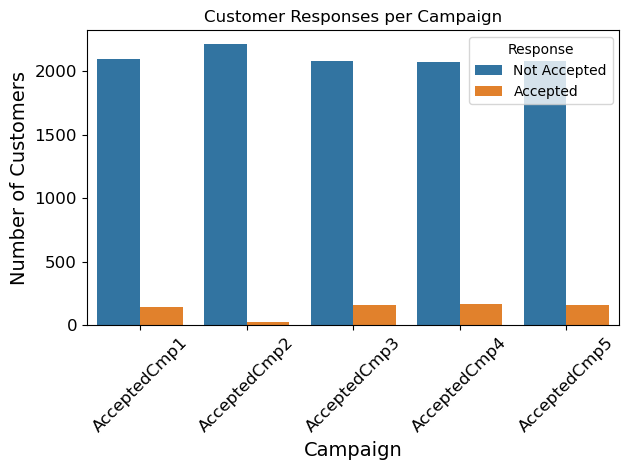

----------Customer personal information-----------
The mean income value is: 52247.25 US


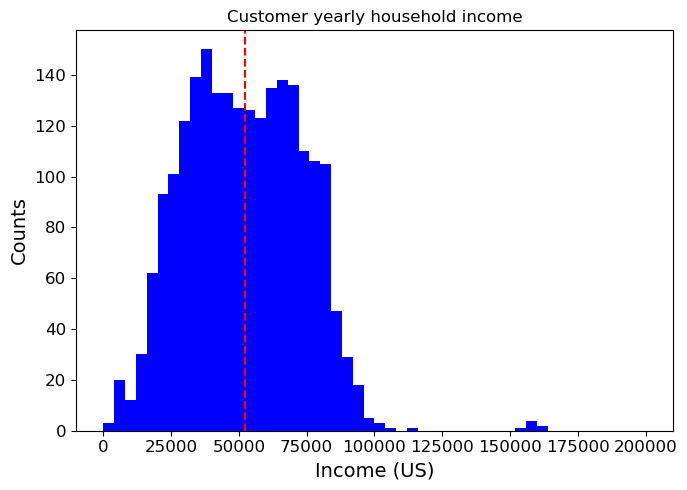

The most common marital status is: Married
The most frequent number of small children is: 0
The most frequent number of teenagers is: 0


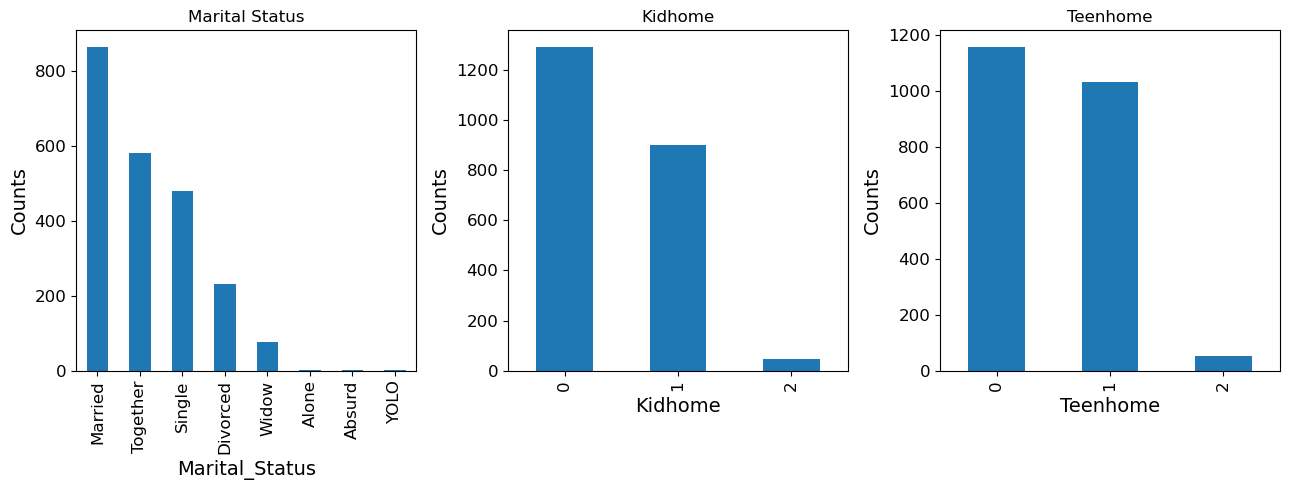

---How much the customer spends in the products---
Product that customer spends more is: Wines


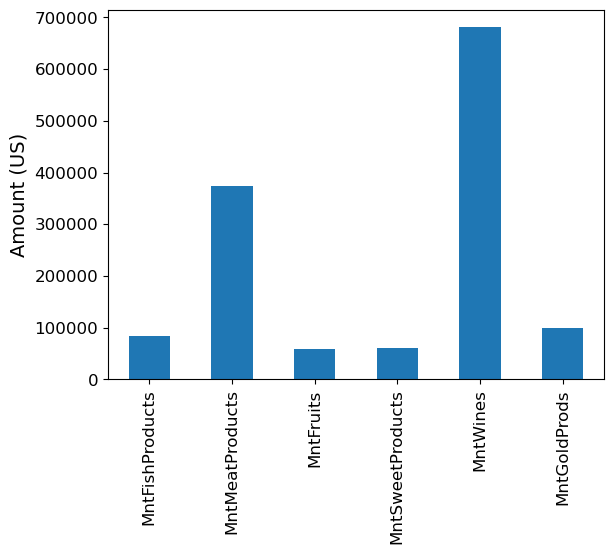

--------Customer interactions with company--------
the most common type of purchase is StorePurchases


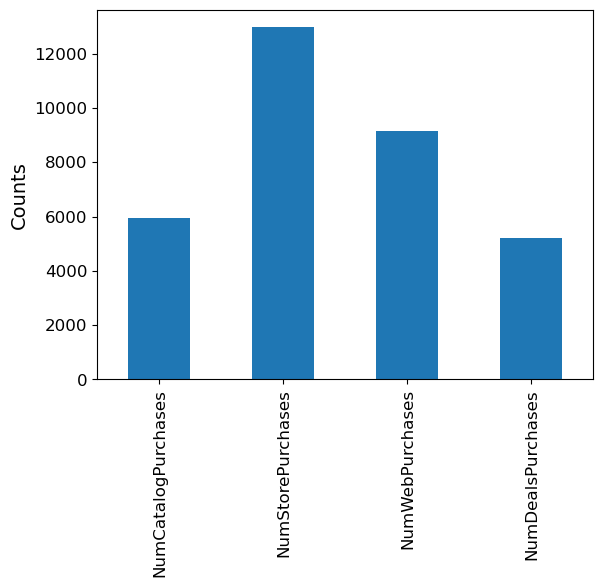

-----------Days since the last purchase-----------
The last time that most customers buy is:  56


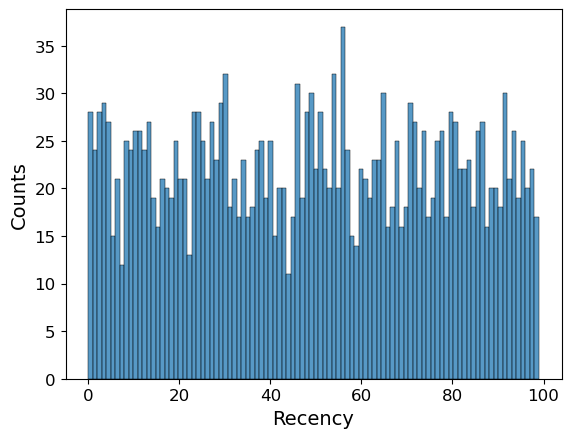

In [54]:
import seaborn as sns
import math

# Campaign behavior 

print("Campaign behavior".center(50,"-"))

camp_response_list = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
## retrieve the most accepted campaign
campaign_counts = df_marketing[camp_response_list].sum()
most_accepted_campaign = campaign_counts.idxmax()
print("The most accepted campaign is: ", most_accepted_campaign[8:])

## Create a data set:  campaign type | Accepted value
df_reshape = df_marketing[camp_response_list].melt(var_name="Campaign", value_name="Accepted")
sns.countplot(data=df_reshape, x="Campaign", hue="Accepted")
plt.legend(title="Response", labels=["Not Accepted", "Accepted"])
plt.ylabel("Number of Customers")
plt.title("Customer Responses per Campaign")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

# Personal Customer Information

print("Customer personal information".center(50,"-"))

mean_in = df_marketing["Income"].mean()
print(f"The mean income value is: {mean_in:.2f} US")

fig, axs = plt.subplots(figsize=(7,5))
axs.hist(df_marketing["Income"], bins = 50, color = 'b', range = (0,200000))
axs.axvline(x=mean_in, color = 'r', linestyle = '--')
plt.xlabel("Income (US)")
plt.ylabel("Counts")
plt.title("Customer yearly household income")
plt.tight_layout()
plt.show()
plt.close()

## Customer Marital status distribution

fig,axs = plt.subplots(1,3, figsize = (13,5))

print("The most common marital status is:", df_marketing["Marital_Status"].value_counts().idxmax())
print("The most frequent number of small children is:", df_marketing["Kidhome"].value_counts().idxmax())
print("The most frequent number of teenagers is:", df_marketing["Teenhome"].value_counts().idxmax())

axs = axs.flatten()
df_marketing["Marital_Status"].value_counts().plot(kind="bar", ax = axs[0])
df_marketing["Kidhome"].value_counts().plot(kind="bar", ax = axs[1])
df_marketing["Teenhome"].value_counts().plot(kind="bar", ax = axs[2])
axs[0].set_title("Marital Status")
axs[1].set_title("Kidhome")
axs[2].set_title("Teenhome")

for ax in axs:
    ax.set_ylabel("Counts")

plt.tight_layout()
plt.show()
plt.close()


# Behavior analysis
print("How much the customer spends in the products".center(50,"-"))
fig, ax = plt.subplots()
amount_prod_list = ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines', 'MntGoldProds'] 
print("Product that customer spends more is:", df_marketing[amount_prod_list].sum().idxmax()[3:])

df_marketing[amount_prod_list].sum().plot(kind="bar")
plt.ylabel("Amount (US)")
plt.show()
plt.close()

df_marketing[amount_prod_list].describe()

# Purchase channel analysis
print("Customer interactions with company".center(50,"-"))

fig, ax = plt.subplots()
purchase_list = ['NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases', 'NumDealsPurchases']
print("the most common type of purchase is", df_marketing[purchase_list].sum().idxmax()[3:])
df_marketing[purchase_list].sum().plot(kind = "bar")
plt.ylabel("Counts")
plt.show()
plt.close()

# Recency analysis
print("Days since the last purchase".center(50,"-"))
fig, ax = plt.subplots()
print("The last time that most customers buy is: ", df_marketing["Recency"].value_counts().idxmax())
sns.histplot(data = df_marketing, x="Recency", bins = 100)
plt.ylabel("Counts")
plt.show()
plt.close()




# Feature Engine